In [ ]:
import os
from pathlib import Path
import matplotlib.pyplot as plt

_TREBL_FIG_DIR = Path.cwd() / 'saved_figures'
_TREBL_FIG_DIR.mkdir(parents=True, exist_ok=True)


def _trebl_notebook_stem():
    session_path = os.environ.get('JPY_SESSION_NAME', '')
    if session_path:
        raw_stem = Path(session_path).stem or 'notebook'
        safe_stem = ''.join(ch if (ch.isalnum() or ch in {'_', '-'}) else '_' for ch in raw_stem)
        return safe_stem.strip('_') or 'notebook'
    return 'notebook'


# Reset counter and stem every time this cell runs so re-running replaces existing images
if hasattr(plt, '_trebl_autosave_original_show'):
    plt.show = plt._trebl_autosave_original_show

plt._trebl_autosave_original_show = plt.show
plt._trebl_autosave_counter = 1
plt._trebl_notebook_stem = _trebl_notebook_stem()


def _trebl_autosave_show(*args, **kwargs):
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        stem = f"{plt._trebl_notebook_stem}_figure_{plt._trebl_autosave_counter:04d}"
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.png', dpi=300, bbox_inches='tight')
        fig.savefig(_TREBL_FIG_DIR / f'{stem}.pdf', dpi=300, bbox_inches='tight')
        plt._trebl_autosave_counter += 1
    return plt._trebl_autosave_original_show(*args, **kwargs)


plt.show = _trebl_autosave_show


In [1]:
from parrot import py_predictor

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

Error importing GPy.
 If trying to run parrot-optimize, make sure to use `pip install idptools-parrot[optimize]`


# Prepping data for fit

In [2]:
exponential_fit = pd.read_csv("../../../output/GCN4_pipeline/speed/exponential_fit.csv", index_col = 0)
exponential_fit

,ADseq,A,A_err,k,k_err,C,C_err,t_half,t_half_err,obs_max,t_half_model_empirical,r_squared,flag,t_half_obsmax,A+C,A*k,1/k
0,AAAQHVPAADGQWLALFPHPSSIDFDFNSFHQSFSSPPPH,3.619457,0.481638,0.115100,0.036830,0.530625,0.319867,6.022144,1.926989,4.035523,4.569138,0.972274,ok,NaN,4.150082,0.416598,8.688118
1,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,1.385225,0.553639,0.074620,0.062932,0.601177,0.059638,9.289001,7.834024,1.838727,3.486974,0.960851,ok,NaN,1.986402,0.103366,13.401196
2,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,2.195991,0.085748,0.146610,0.016995,-0.066138,0.040876,4.727820,0.548043,2.102846,4.869739,0.985961,ok,NaN,2.129853,0.321955,6.820803
3,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN,1.992776,0.123694,0.159460,0.019381,-0.286056,0.118027,4.346844,0.528314,1.690053,5.230461,0.995732,ok,NaN,1.706721,0.317768,6.271170
4,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,2.520940,0.186441,0.155566,0.024089,1.109990,0.154746,4.455660,0.689937,3.607231,2.044088,0.998874,ok,NaN,3.630930,0.392171,6.428159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4708,YTNLTTPGTSYIDSPLYIADSTDTSPLFATDGLGADADSW,3.368061,0.071460,0.141788,0.007293,0.069468,0.051669,4.888605,0.251443,3.389661,4.629259,0.999213,ok,NaN,3.437529,0.477552,7.052766
4709,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,3.441662,0.104211,0.157731,0.008328,0.451281,0.102140,4.394499,0.232036,3.862623,3.547094,0.990357,ok,NaN,3.892943,0.542856,6.339923
4710,YTTASSSSFSSASANILPRDFSVFTTDSQSSWLPSSSPSL,2.523455,0.092592,0.133525,0.011832,0.311140,0.065568,5.191132,0.460007,2.788641,4.208417,0.997692,ok,NaN,2.834594,0.336945,7.489220
4711,YVEGLRWVTWGQMGHVELSPVSRFTATIPSHDFQSFVTDH,1.689938,0.100656,0.055910,0.007066,0.016752,0.031002,12.397552,1.566757,1.390878,9.198397,0.998031,ok,NaN,1.706690,0.094484,17.885887


In [3]:
#exponential_fit[["ADseq", "A*k"]].to_csv("../../../output/GCN4_pipeline/speed/PARROT/exponential_speed_input.txt", sep="\t", header=False)

In [4]:
exponential_fit[["ADseq", "A+C"]].to_csv("../../../output/GCN4_pipeline/speed/PARROT/exponential_strength_input_more_seqs.txt", sep="\t", header=False)

In [5]:
exponential_fit[["ADseq", "k"]].to_csv("../../../output/GCN4_pipeline/speed/PARROT/exponential_speed_input_k_more_seqs.txt", sep="\t", header=False)

# GCN4 trained models

In [11]:
def return_preds(path):
    gcn4_speed_preds = pd.read_csv(path, sep = "\t", header = None)
    gcn4_speed_preds["class"] = gcn4_speed_preds[0].str.split("_").str[1].str.split(" ").str[0]
    gcn4_speed_preds["seq"] = gcn4_speed_preds[0].str.split(" ").str[1].str.split(" ").str[0]
    gcn4_speed_preds["val"] = gcn4_speed_preds[0].str.split(" ").str[2].astype(float)
    gcn4_speed_preds = gcn4_speed_preds.drop(columns = 0)
    gcn4_speed_preds = pd.pivot(gcn4_speed_preds, index = "seq", columns = "class", values='val').reset_index()
    return gcn4_speed_preds

In [15]:
gcn4_speed_preds = return_preds("../../../output/GCN4_pipeline/speed/PARROT/exponential_speed_predictions.tsv")
gcn4_speed_preds

class,seq,PRED,TRUE
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0.248494,0.103366
1,ADIDLFDDFTSGAGGDLSTLSFDFDMSANANFTAINGAPA,0.639667,0.939468
2,AFVSGTVSPKDLHVDTAPPSTTFTDLSTPSFESSGYFSHD,0.296496,0.343655
3,AGLPSGTVSPTDLMLDASAPSSATFTDLSTPPFDSPGYFS,0.375349,0.531135
4,AGLQNDSPWEAPASAFTTINPHSVSGSTRTISPKDIFADP,0.118995,0.263107
...,...,...,...
228,YDSTMNLSSSSSTNMGTVSPKDLLRDPFASAPNSTAFTNL,0.211439,0.243460
229,YFSHDPSPMLSDDFGSEQWDSLFPANDPFSAALDSATLGL,0.872227,0.837221
230,YNESPDFTDGYDVSPNFGSADFEGSGDPWFPLFPQETTTV,0.597343,0.654755
231,YRDHLIANLTLAHEVDLFGLPSTDFPASMDSPLAFHDLGL,0.422536,0.492747


In [16]:
gcn4_speed_k_preds = return_preds("../../../output/GCN4_pipeline/speed/PARROT/exponential_speed_k_predictions.tsv")
gcn4_speed_k_preds

class,seq,PRED,TRUE
0,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,0.140482,0.146610
1,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,0.165988,0.155566
2,AASNLGTVSPQDLLVQEPFMSAPNSAALTALTSPSLYNGS,0.088745,0.110655
3,ADFEEFTGFEGGASTAYSSPSAPSVFDMPSGSHNIGTVSP,0.116053,0.131298
4,AFTNLTSPSTYNESPDFGVDDNFDVSPFVGNNRDLDHALS,0.113682,0.125987
...,...,...,...
228,YDSTMNLSSSSSTNMGTVSPKDLLRDPFASAPNSTAFTNL,0.112500,0.117585
229,YDTSPLYNGDDVSSDGQWYSLFPETNPDPEDSVSPPMPNI,0.149736,0.134194
230,YNESPDFTDGYDVSPNFGSADFEGSGDPWFPLFPQETTTV,0.173580,0.173539
231,YNGSPDFDSFDVSPNFGTAEFDNGPSDPWYPLFPSDTASH,0.198065,0.177767


In [18]:
gcn4_speed_k_preds_more_seqs = return_preds("../../../output/GCN4_pipeline/speed/PARROT/exponential_speed_k_more_seqs_predictions.tsv")
gcn4_speed_k_preds_more_seqs

class,seq,PRED,TRUE
0,ADIDLFDDFTSGAGGDLSTLSFDFDMSANANFTAINGAPA,0.148176,0.223308
1,ADLNLHLGTTDFESINHPAPASDSVQTISPKDIMMDTMSA,0.086563,0.147055
2,ADMAFDTPIVDPSPLEPMEMWQSLFPEWSESSEPKQDKDD,0.189167,0.196340
3,ADNSPMFESPESEDPNNWVSLFADETTLATTPAVSRAPAA,0.116520,0.152248
4,ADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSIG,0.133640,0.136189
...,...,...,...
611,YLSAPSSTALTALTSPSIFDGSPDFDTFDISPSFGHSDLD,0.106205,0.101720
612,YPQTQFAQRAGLQQPALPAQTDKAQEIWDDKAFEEAFDSA,0.160010,0.090388
613,YPVDYDPASLQYMLEFFRNVAQSIPSSSPSPTSSDPNAVS,0.097686,0.128453
614,YSSPAVPTIYDPHMNLSSSTSSTNMGTVSPQDLLRDPFAS,0.106327,0.158137


In [19]:
gcn4_strength_preds = return_preds("../../../output/GCN4_pipeline/speed/PARROT/exponential_strength_predictions.tsv")
gcn4_strength_preds

class,seq,PRED,TRUE
0,ADIDLFDDFTSGAGGDLSTLSFDFDMSANANFTAINGAPA,4.421796,4.631955
1,AEPDAELMPFPMAFTQNIDSFAPTTVSASVSPASSSVGPE,2.489271,1.167244
2,AFDGGASTTTYSSPAMPNLFDMSGASSSSTNLGTVSPQDL,1.845247,1.439563
3,AFQAGGFSLEQVSAFTAINDPSVASGSTRTVSPKDIFADA,2.287121,2.403852
4,ALFSPQDFPVFTTDSTQSTWPPSSSSSQPAPSAHQHSFQS,1.172266,1.401853
...,...,...,...
228,VSPQDLLMHEPFMSAPNSSALTALTSPSIYNESPDFTDGY,2.999378,2.623477
229,VSPQELLLHEPYLSAPSSTALTALTSPSIFDGSPDFDTFD,3.462940,3.505216
230,VSPRDLFIDASAPPSATFTDLSTPPLDTPGYFSQNTSPMI,3.161624,2.745010
231,VTKDVSLFESVGYSDPNFASMNESVGSSGTVSPKDLLRDP,2.576162,2.236151


In [21]:
gcn4_strength_preds_more_seqs = return_preds("../../../output/GCN4_pipeline/speed/PARROT/exponential_strength_more_seqs_predictions.tsv")
gcn4_strength_preds_more_seqs

class,seq,PRED,TRUE
0,AAPQQPQQIDPLVASLTPATGTISPQELMGHSFGNDDFDA,1.353091,2.563030
1,AATIPPLDFSVFTTDSLQQSWLPSSSSSPPAPSAQPPNFQ,2.926424,2.832088
2,ADMDLFDEFTAFEGGASTTQNAFPSAYSSPAVPTIYDPSA,3.567163,3.662189
3,AFSSPAMTGCDLDVGSASSSNLGTVSPGELLLQEQFSAPN,2.452113,2.067217
4,AFSSPAVPTNYDFNAGNSTSQSTNMGTVSPQDLFVRDSFA,2.989732,2.829656
...,...,...,...
611,YNESPDFNDGYDVSPSFDSGDFGSADFDTTAGDPWFPLFP,5.073159,5.022541
612,YQFTPSQPQDNSIRTPEARQISQQQQQQPILDPNTAAHYF,1.427190,0.687916
613,YRDHLIANLTLAHEVDLFGLPSTDFPASMDSPLAFHDLGL,4.431010,4.245728
614,YSLFPDAAPDTEESSVSPPNPTLPVQGSPLIGNGYSDDDI,1.697445,0.446060


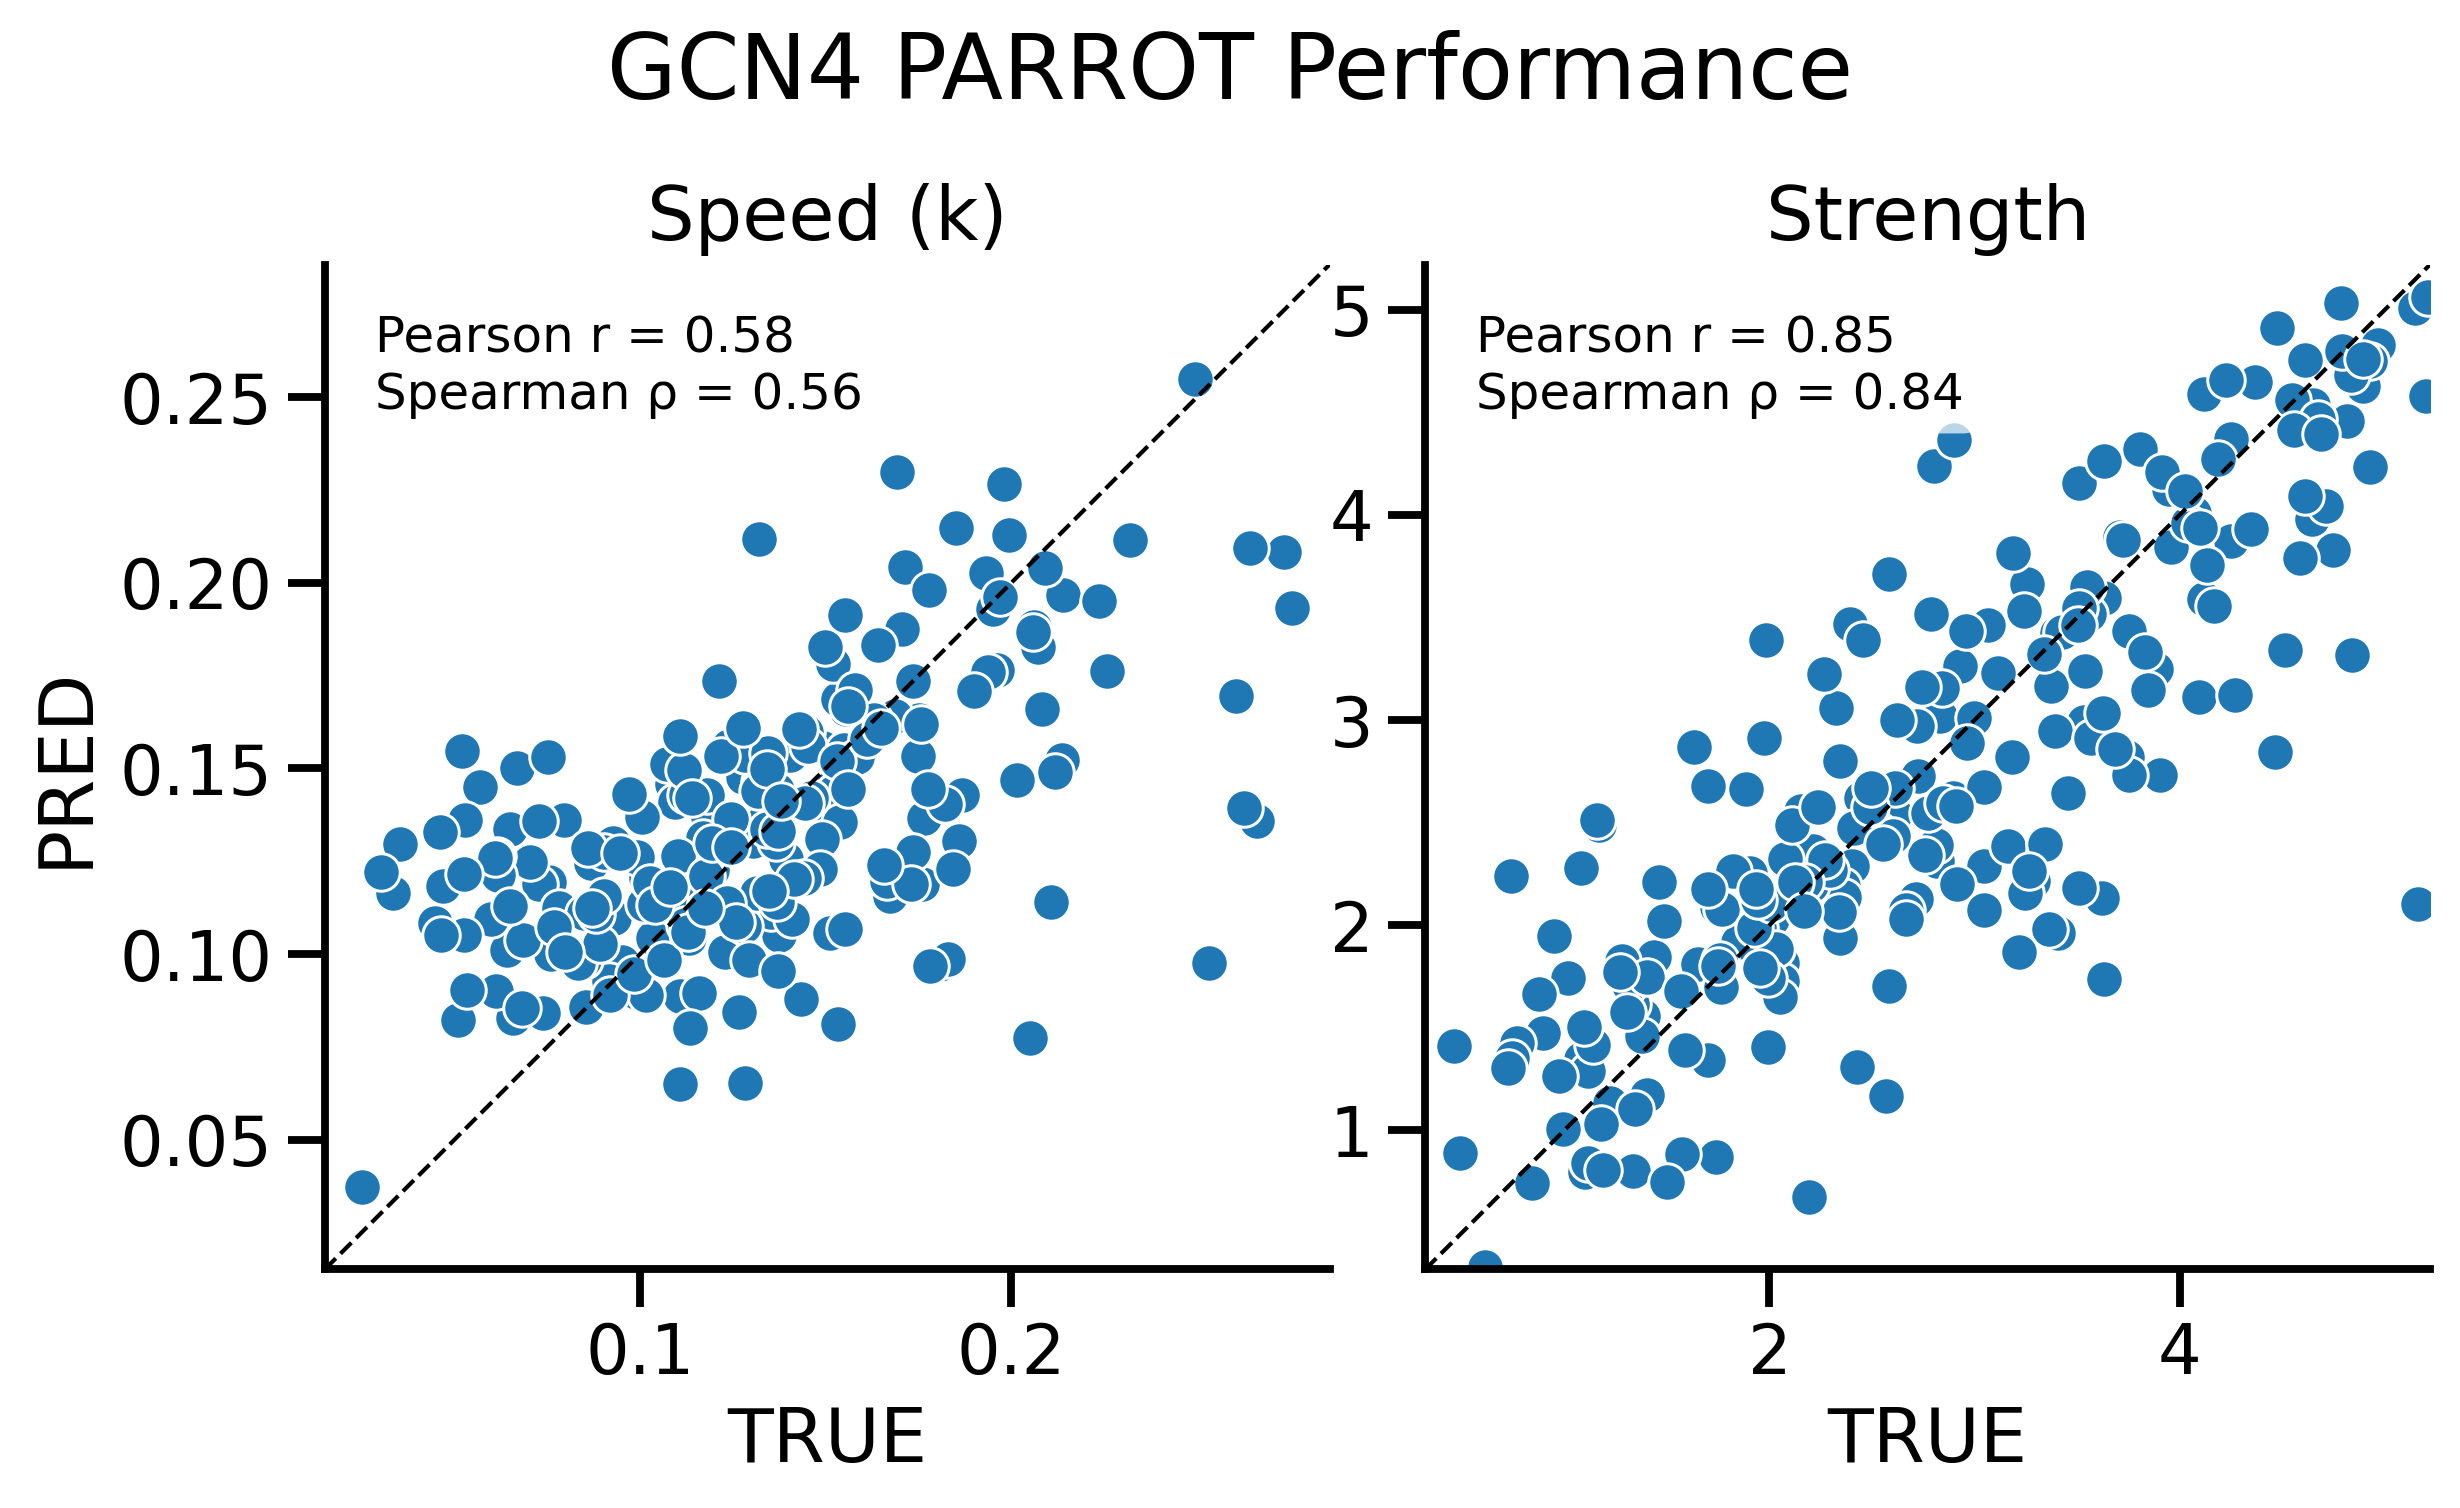

In [22]:
fig,axs = plt.subplots(1,2, dpi = 300, figsize = (8,5))

sns.set_context('talk')



ax = axs[0]
x = gcn4_speed_k_preds["TRUE"]
y = gcn4_speed_k_preds["PRED"]

sns.scatterplot(data=gcn4_speed_k_preds, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_title("Speed (k)")

ax = axs[1]
x = gcn4_strength_preds["TRUE"]
y = gcn4_strength_preds["PRED"]

sns.scatterplot(data=gcn4_strength_preds, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_ylabel("")
ax.set_title("Strength")

fig.suptitle("GCN4 PARROT Performance")
fig.tight_layout(pad = 0)
sns.despine()
plt.show()

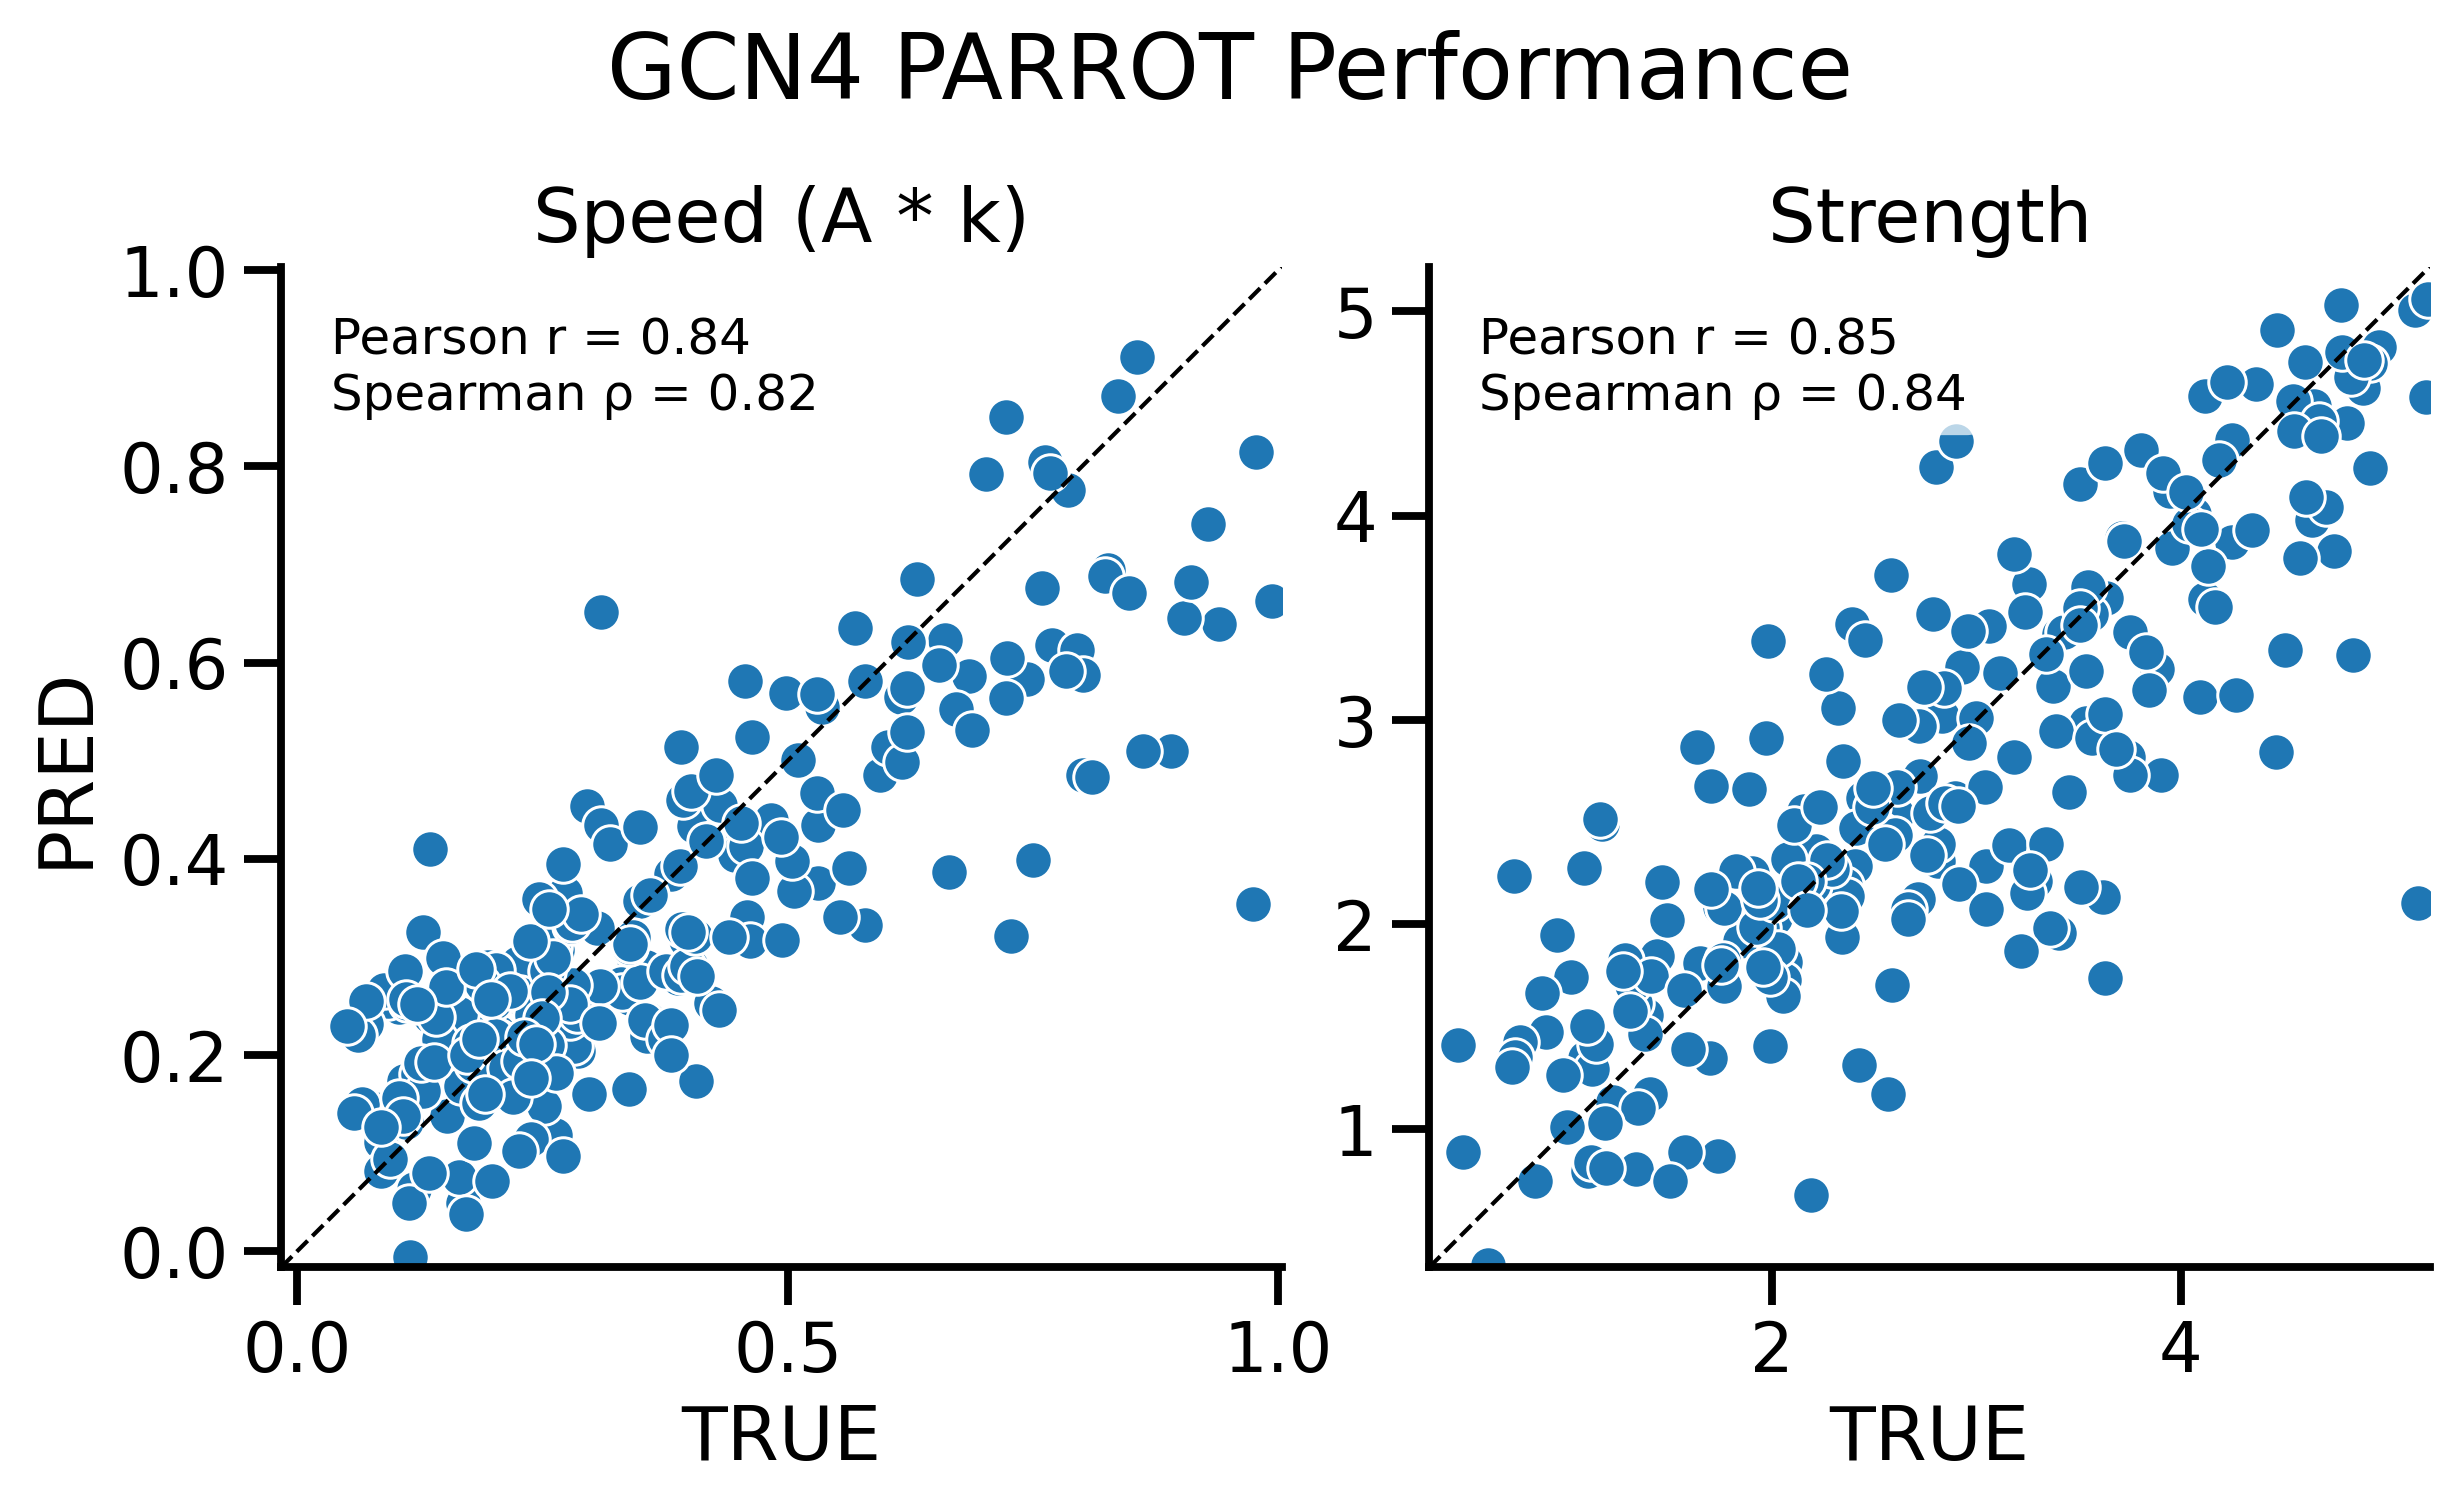

In [23]:
fig,axs = plt.subplots(1,2, dpi = 300, figsize = (8,5))

sns.set_context('talk')



ax = axs[0]
x = gcn4_speed_preds["TRUE"]
y = gcn4_speed_preds["PRED"]

sns.scatterplot(data=gcn4_speed_preds, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_title("Speed (A * k)")

ax = axs[1]
x = gcn4_strength_preds["TRUE"]
y = gcn4_strength_preds["PRED"]

sns.scatterplot(data=gcn4_strength_preds, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_ylabel("")
ax.set_title("Strength")

fig.suptitle("GCN4 PARROT Performance")
fig.tight_layout(pad = 0)
sns.despine()
plt.show()

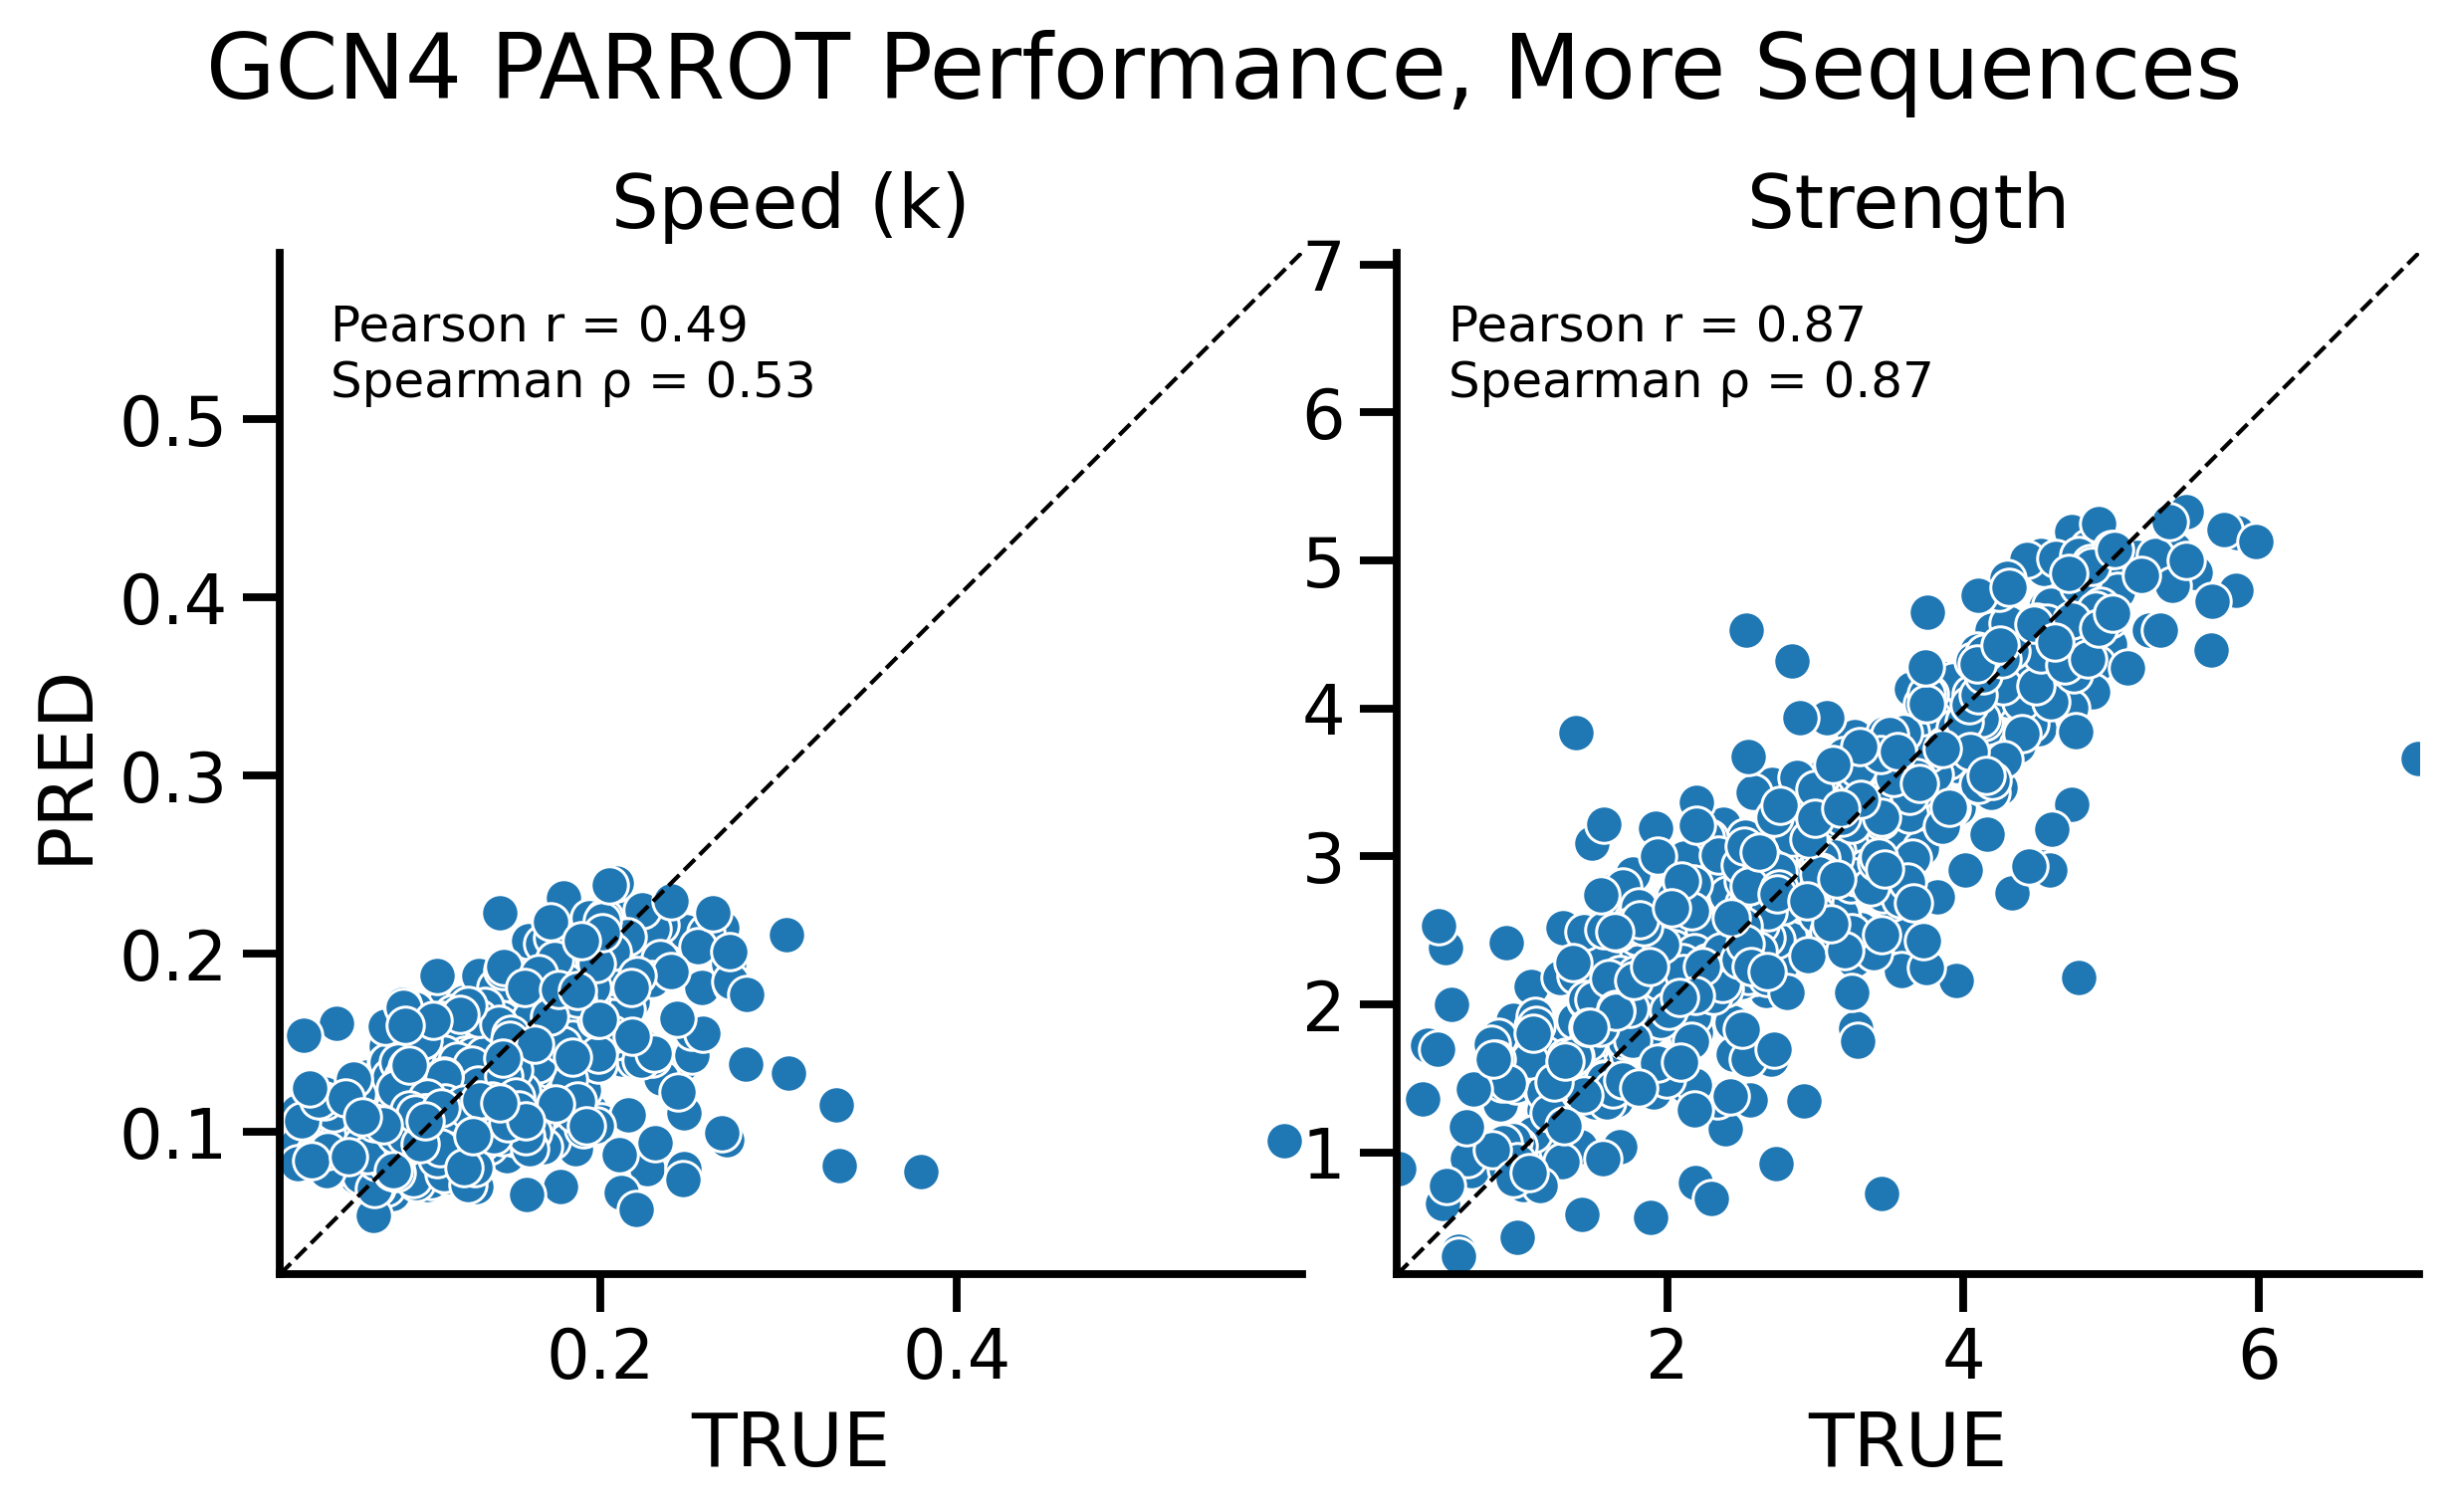

In [27]:
fig,axs = plt.subplots(1,2, dpi = 300, figsize = (8,5))

sns.set_context('talk')



ax = axs[0]
x = gcn4_speed_k_preds_more_seqs["TRUE"]
y = gcn4_speed_k_preds_more_seqs["PRED"]

sns.scatterplot(data=gcn4_speed_k_preds_more_seqs, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_title("Speed (k)")

ax = axs[1]
x = gcn4_strength_preds_more_seqs["TRUE"]
y = gcn4_strength_preds_more_seqs["PRED"]

sns.scatterplot(data=gcn4_strength_preds_more_seqs, x="TRUE", y="PRED", ax = ax)

# limits
min_val = min(x.min(), y.min()) - 0.01
max_val = max(x.max(), y.max()) + 0.01

ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)

# y = x line
ax.plot([min_val, max_val], [min_val, max_val],
        linestyle="--", color="black", linewidth=1)

# correlations
pearson_r, _ = pearsonr(x, y)
spearman_r, _ = spearmanr(x, y)

# text annotation
ax.text(
    0.05, 0.95,
    f"Pearson r = {pearson_r:.2f}\nSpearman ρ = {spearman_r:.2f}",
    transform=ax.transAxes,
    va="top",
    fontsize=12,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7, edgecolor="none")
)

ax.set_aspect('equal', adjustable='box')
ax.set_ylabel("")
ax.set_title("Strength")

fig.suptitle("GCN4 PARROT Performance, More Sequences")
fig.tight_layout(pad = 0)
sns.despine()
plt.show()

# GCN4 trained model

In [24]:
ChopTFs_train_speed_predictor = py_predictor.Predictor("../../../output/ChopTFs_pipeline/speed/PARROT/exponential_speed", 
                                                dtype="sequence")
ChopTFs_train_speed_predictor

In [25]:
gcn4_speed_preds["ChopTFs_pred"] = gcn4_speed_preds["seq"].apply(lambda seq: ChopTFs_train_speed_predictor.predict(seq)[0])
gcn4_speed_preds

class,seq,PRED,TRUE,ChopTFs_pred
0,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0.248494,0.103366,0.159989
1,ADIDLFDDFTSGAGGDLSTLSFDFDMSANANFTAINGAPA,0.639667,0.939468,0.246650
2,AFVSGTVSPKDLHVDTAPPSTTFTDLSTPSFESSGYFSHD,0.296496,0.343655,0.089150
3,AGLPSGTVSPTDLMLDASAPSSATFTDLSTPPFDSPGYFS,0.375349,0.531135,0.167849
4,AGLQNDSPWEAPASAFTTINPHSVSGSTRTISPKDIFADP,0.118995,0.263107,0.118056
...,...,...,...,...
228,YDSTMNLSSSSSTNMGTVSPKDLLRDPFASAPNSTAFTNL,0.211439,0.243460,0.073519
229,YFSHDPSPMLSDDFGSEQWDSLFPANDPFSAALDSATLGL,0.872227,0.837221,0.196539
230,YNESPDFTDGYDVSPNFGSADFEGSGDPWFPLFPQETTTV,0.597343,0.654755,0.202231
231,YRDHLIANLTLAHEVDLFGLPSTDFPASMDSPLAFHDLGL,0.422536,0.492747,0.091075


In [26]:
ChopTFs_train_speed_k_predictor = py_predictor.Predictor("../../../output/ChopTFs_pipeline/speed/PARROT/exponential_speed_k", 
                                                dtype="sequence")
ChopTFs_train_speed_k_predictor

In [28]:
gcn4_speed_k_preds["ChopTFs_pred"] = gcn4_speed_k_preds["seq"].apply(lambda seq: ChopTFs_train_speed_k_predictor.predict(seq)[0])
gcn4_speed_k_preds

class,seq,PRED,TRUE,GCN4_pred,ChopTFs_pred
0,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS,0.140482,0.146610,0.094612,0.094612
1,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI,0.165988,0.155566,0.107054,0.107054
2,AASNLGTVSPQDLLVQEPFMSAPNSAALTALTSPSLYNGS,0.088745,0.110655,0.103919,0.103919
3,ADFEEFTGFEGGASTAYSSPSAPSVFDMPSGSHNIGTVSP,0.116053,0.131298,0.111516,0.111516
4,AFTNLTSPSTYNESPDFGVDDNFDVSPFVGNNRDLDHALS,0.113682,0.125987,0.094579,0.094579
...,...,...,...,...,...
228,YDSTMNLSSSSSTNMGTVSPKDLLRDPFASAPNSTAFTNL,0.112500,0.117585,0.105551,0.105551
229,YDTSPLYNGDDVSSDGQWYSLFPETNPDPEDSVSPPMPNI,0.149736,0.134194,0.094687,0.094687
230,YNESPDFTDGYDVSPNFGSADFEGSGDPWFPLFPQETTTV,0.173580,0.173539,0.108205,0.108205
231,YNGSPDFDSFDVSPNFGTAEFDNGPSDPWYPLFPSDTASH,0.198065,0.177767,0.102402,0.102402


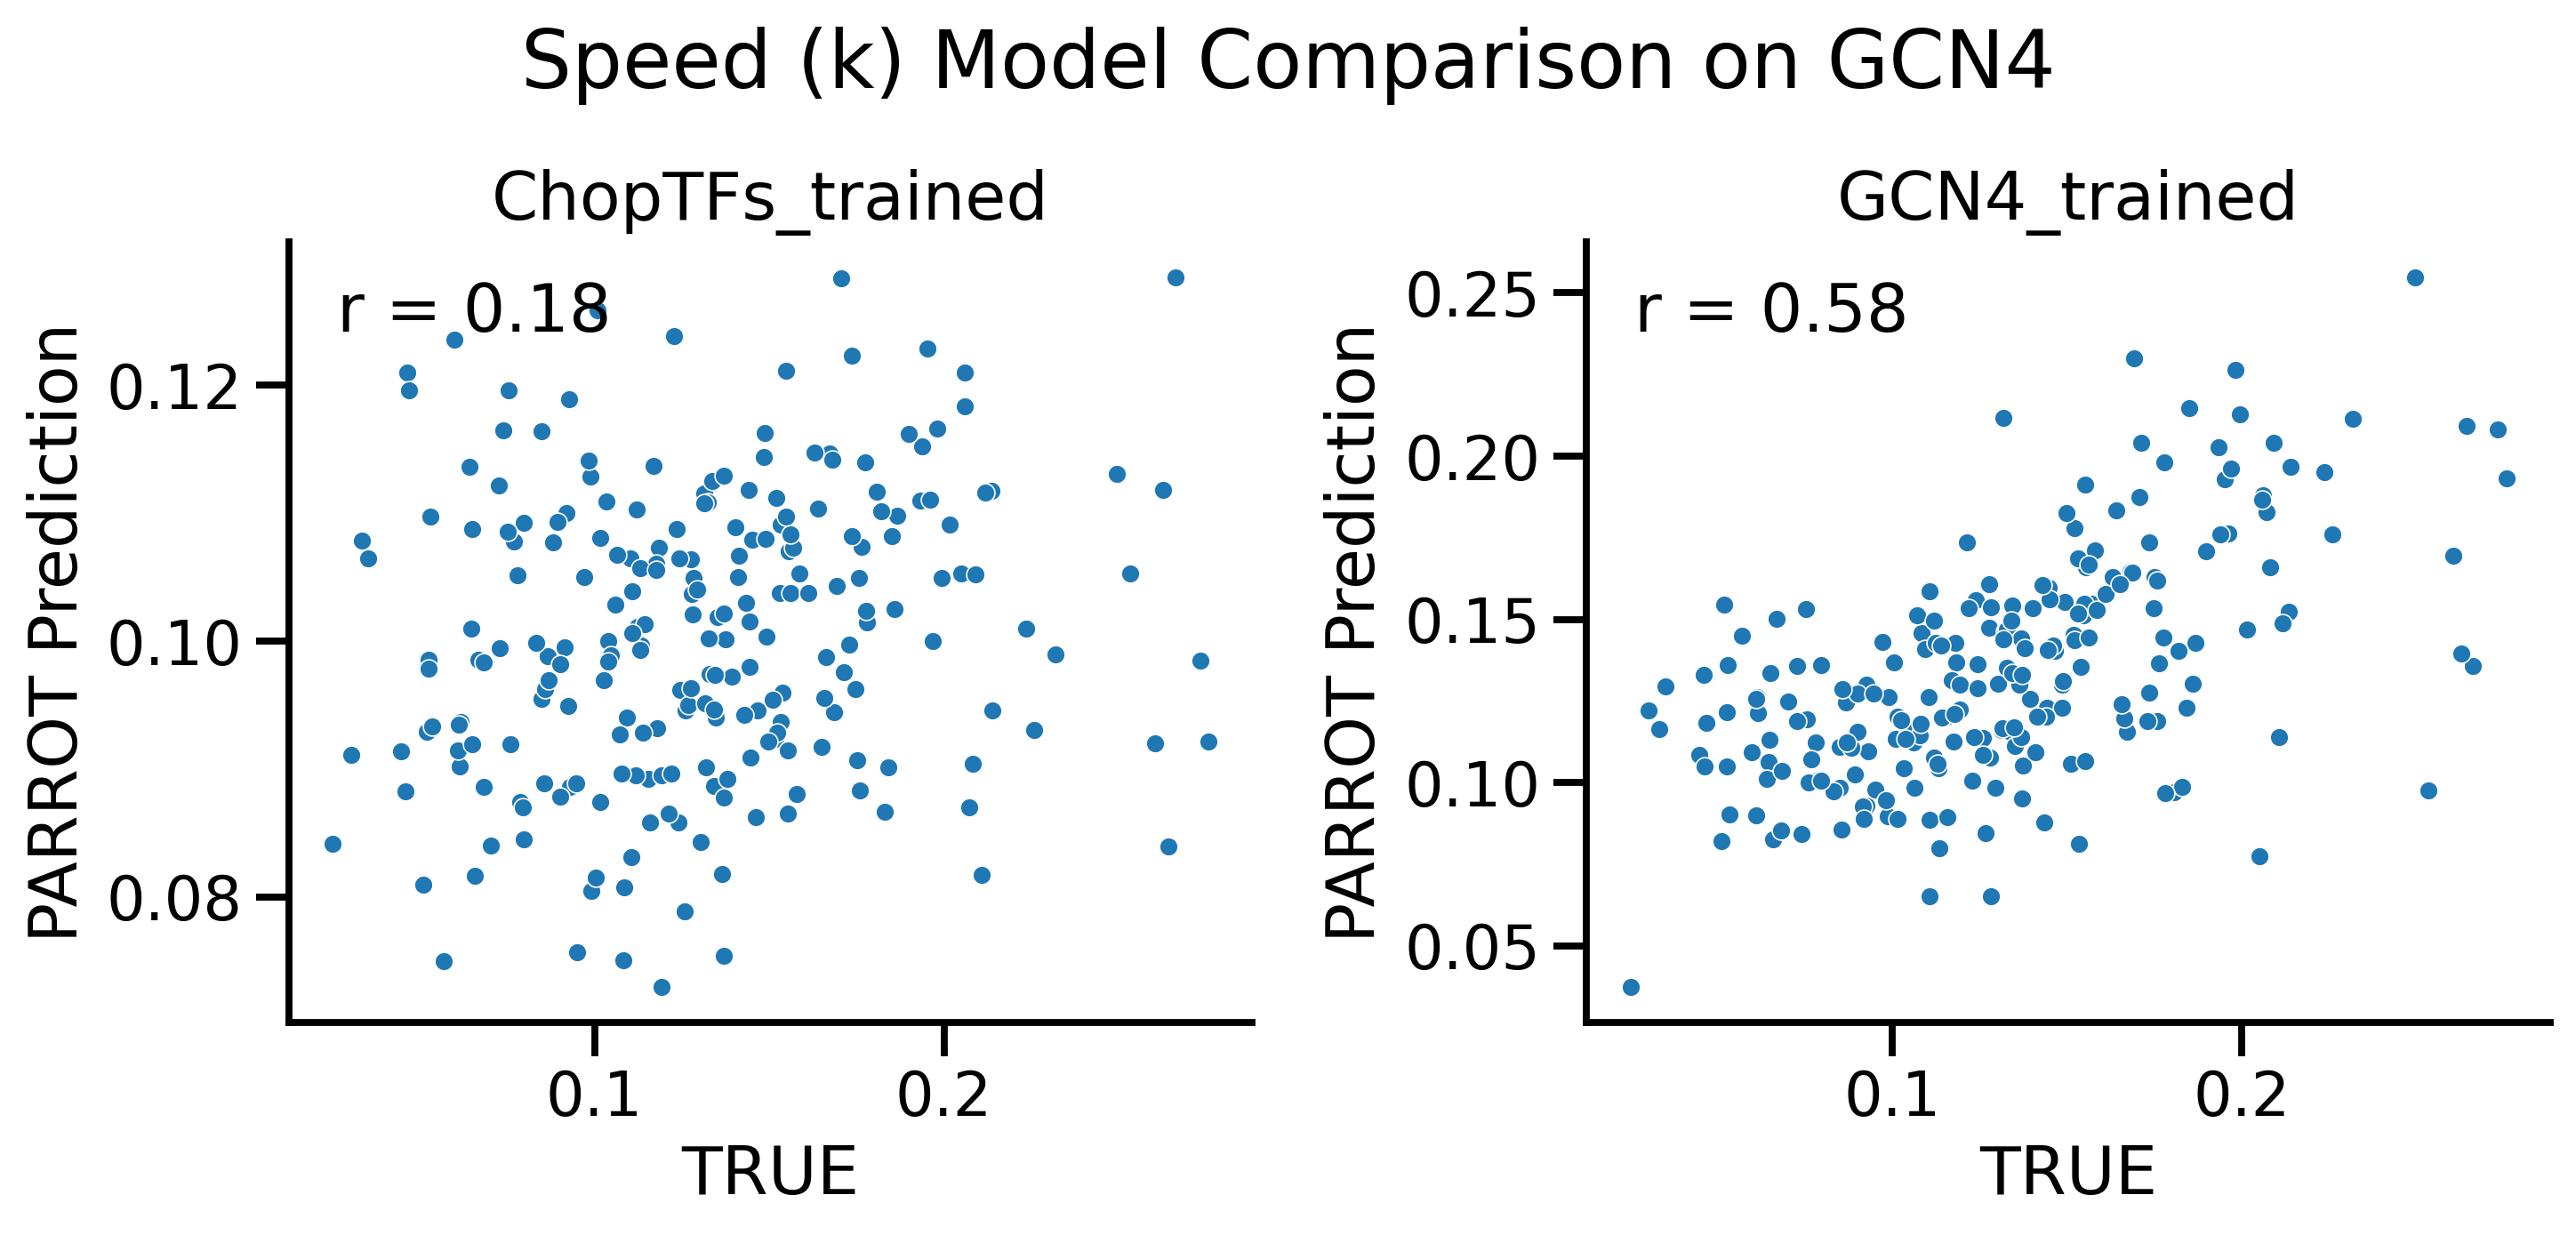

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sns.set_context("talk")

df = gcn4_speed_k_preds.rename(columns = {"PRED" : "GCN4_trained", "ChopTFs_pred" : "ChopTFs_trained"})
cols = ["ChopTFs_trained", "GCN4_trained"]
true = df["TRUE"]

fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex=True, dpi = 300)

for ax, col in zip(axes, cols):
    x = true
    y = df[col]

    sns.scatterplot(x=x, y=y, ax=ax, s=25, alpha=1)


    # Pearson
    r, _ = pearsonr(x, y)
    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        va="top"
    )

    ax.set_title(f"{col}")
    ax.set_xlabel("TRUE")
    ax.set_ylabel("PARROT Prediction")

fig.suptitle("Speed (k) Model Comparison on GCN4", y = 0.94)
sns.despine()
plt.tight_layout()
plt.show()

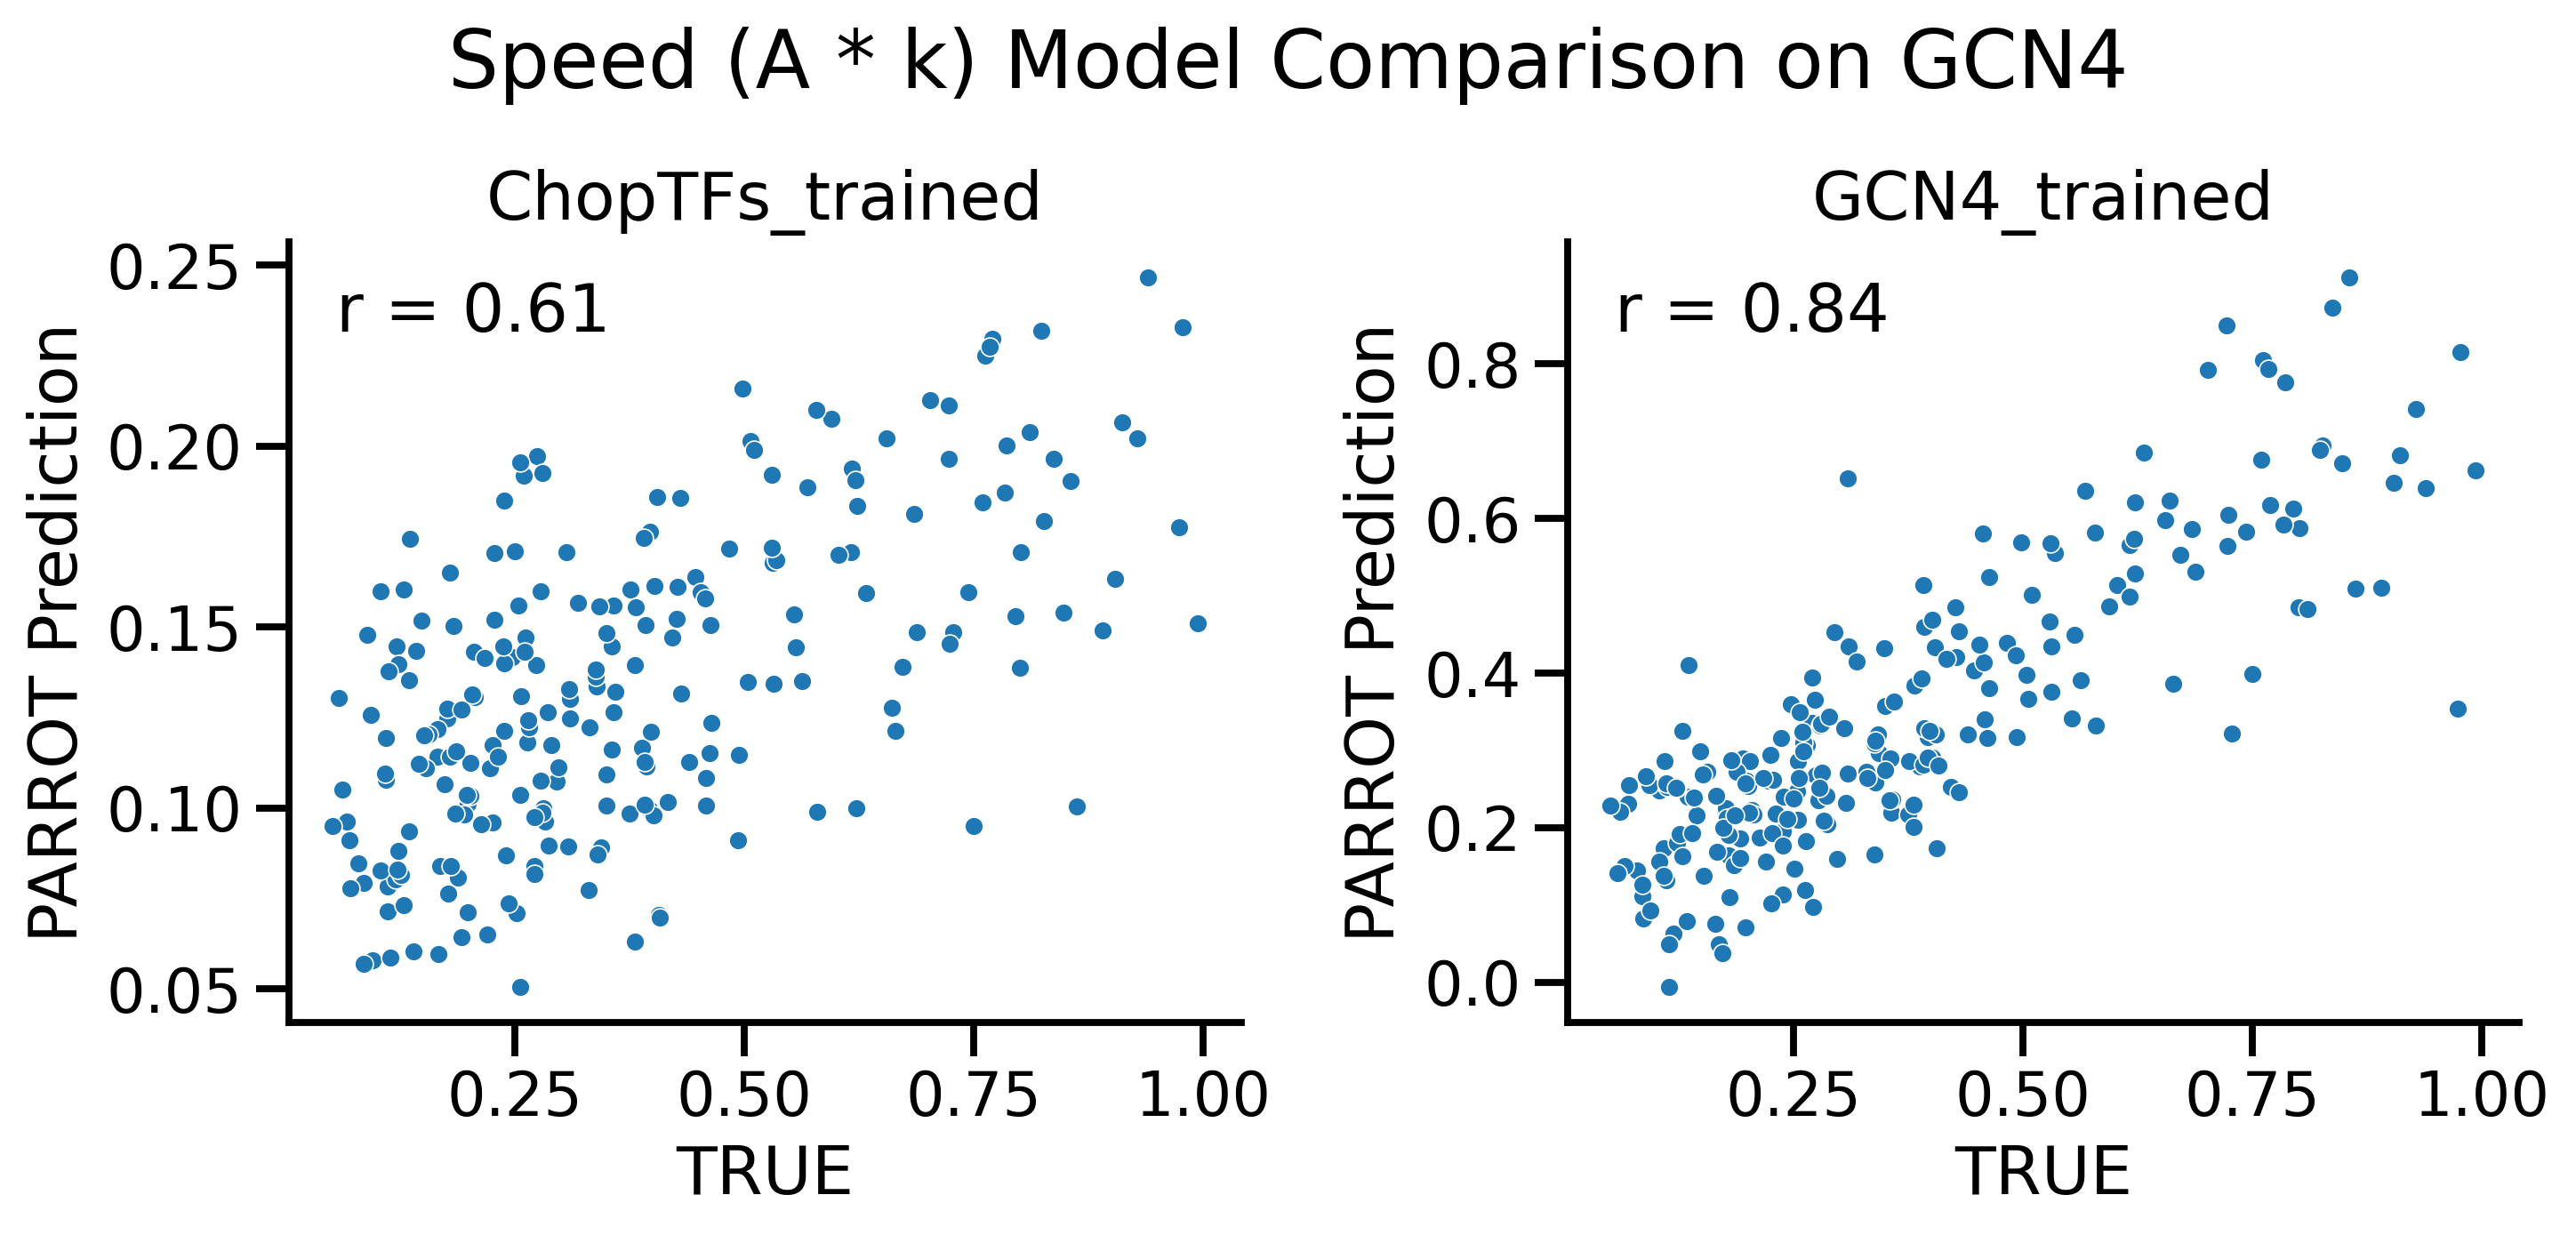

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sns.set_context("talk")

df = gcn4_speed_preds.rename(columns = {"PRED" : "GCN4_trained", "ChopTFs_pred" : "ChopTFs_trained"})
cols = ["ChopTFs_trained", "GCN4_trained"]
true = df["TRUE"]

fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex=True, dpi = 300)

for ax, col in zip(axes, cols):
    x = true
    y = df[col]

    sns.scatterplot(x=x, y=y, ax=ax, s=25, alpha=1)


    # Pearson
    r, _ = pearsonr(x, y)
    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        va="top"
    )

    ax.set_title(f"{col}")
    ax.set_xlabel("TRUE")
    ax.set_ylabel("PARROT Prediction")

fig.suptitle("Speed (A * k) Model Comparison on GCN4", y = 0.94)
sns.despine()
plt.tight_layout()
plt.show()

In [32]:
ChopTFs_train_strength_predictor = py_predictor.Predictor("../../../output/ChopTFs_pipeline/speed/PARROT/exponential_strength", 
                                                dtype="sequence")
ChopTFs_train_strength_predictor

In [33]:
gcn4_strength_preds["ChopTFs_pred"] = gcn4_strength_preds["seq"].apply(lambda seq: ChopTFs_train_strength_predictor.predict(seq)[0])
gcn4_strength_preds

class,seq,PRED,TRUE,ChopTFs_pred
0,ADIDLFDDFTSGAGGDLSTLSFDFDMSANANFTAINGAPA,4.421796,4.631955,1.646502
1,AEPDAELMPFPMAFTQNIDSFAPTTVSASVSPASSSVGPE,2.489271,1.167244,1.187822
2,AFDGGASTTTYSSPAMPNLFDMSGASSSSTNLGTVSPQDL,1.845247,1.439563,0.997365
3,AFQAGGFSLEQVSAFTAINDPSVASGSTRTVSPKDIFADA,2.287121,2.403852,1.085975
4,ALFSPQDFPVFTTDSTQSTWPPSSSSSQPAPSAHQHSFQS,1.172266,1.401853,0.993780
...,...,...,...,...
228,VSPQDLLMHEPFMSAPNSSALTALTSPSIYNESPDFTDGY,2.999378,2.623477,1.175676
229,VSPQELLLHEPYLSAPSSTALTALTSPSIFDGSPDFDTFD,3.462940,3.505216,1.355493
230,VSPRDLFIDASAPPSATFTDLSTPPLDTPGYFSQNTSPMI,3.161624,2.745010,0.918522
231,VTKDVSLFESVGYSDPNFASMNESVGSSGTVSPKDLLRDP,2.576162,2.236151,0.944772


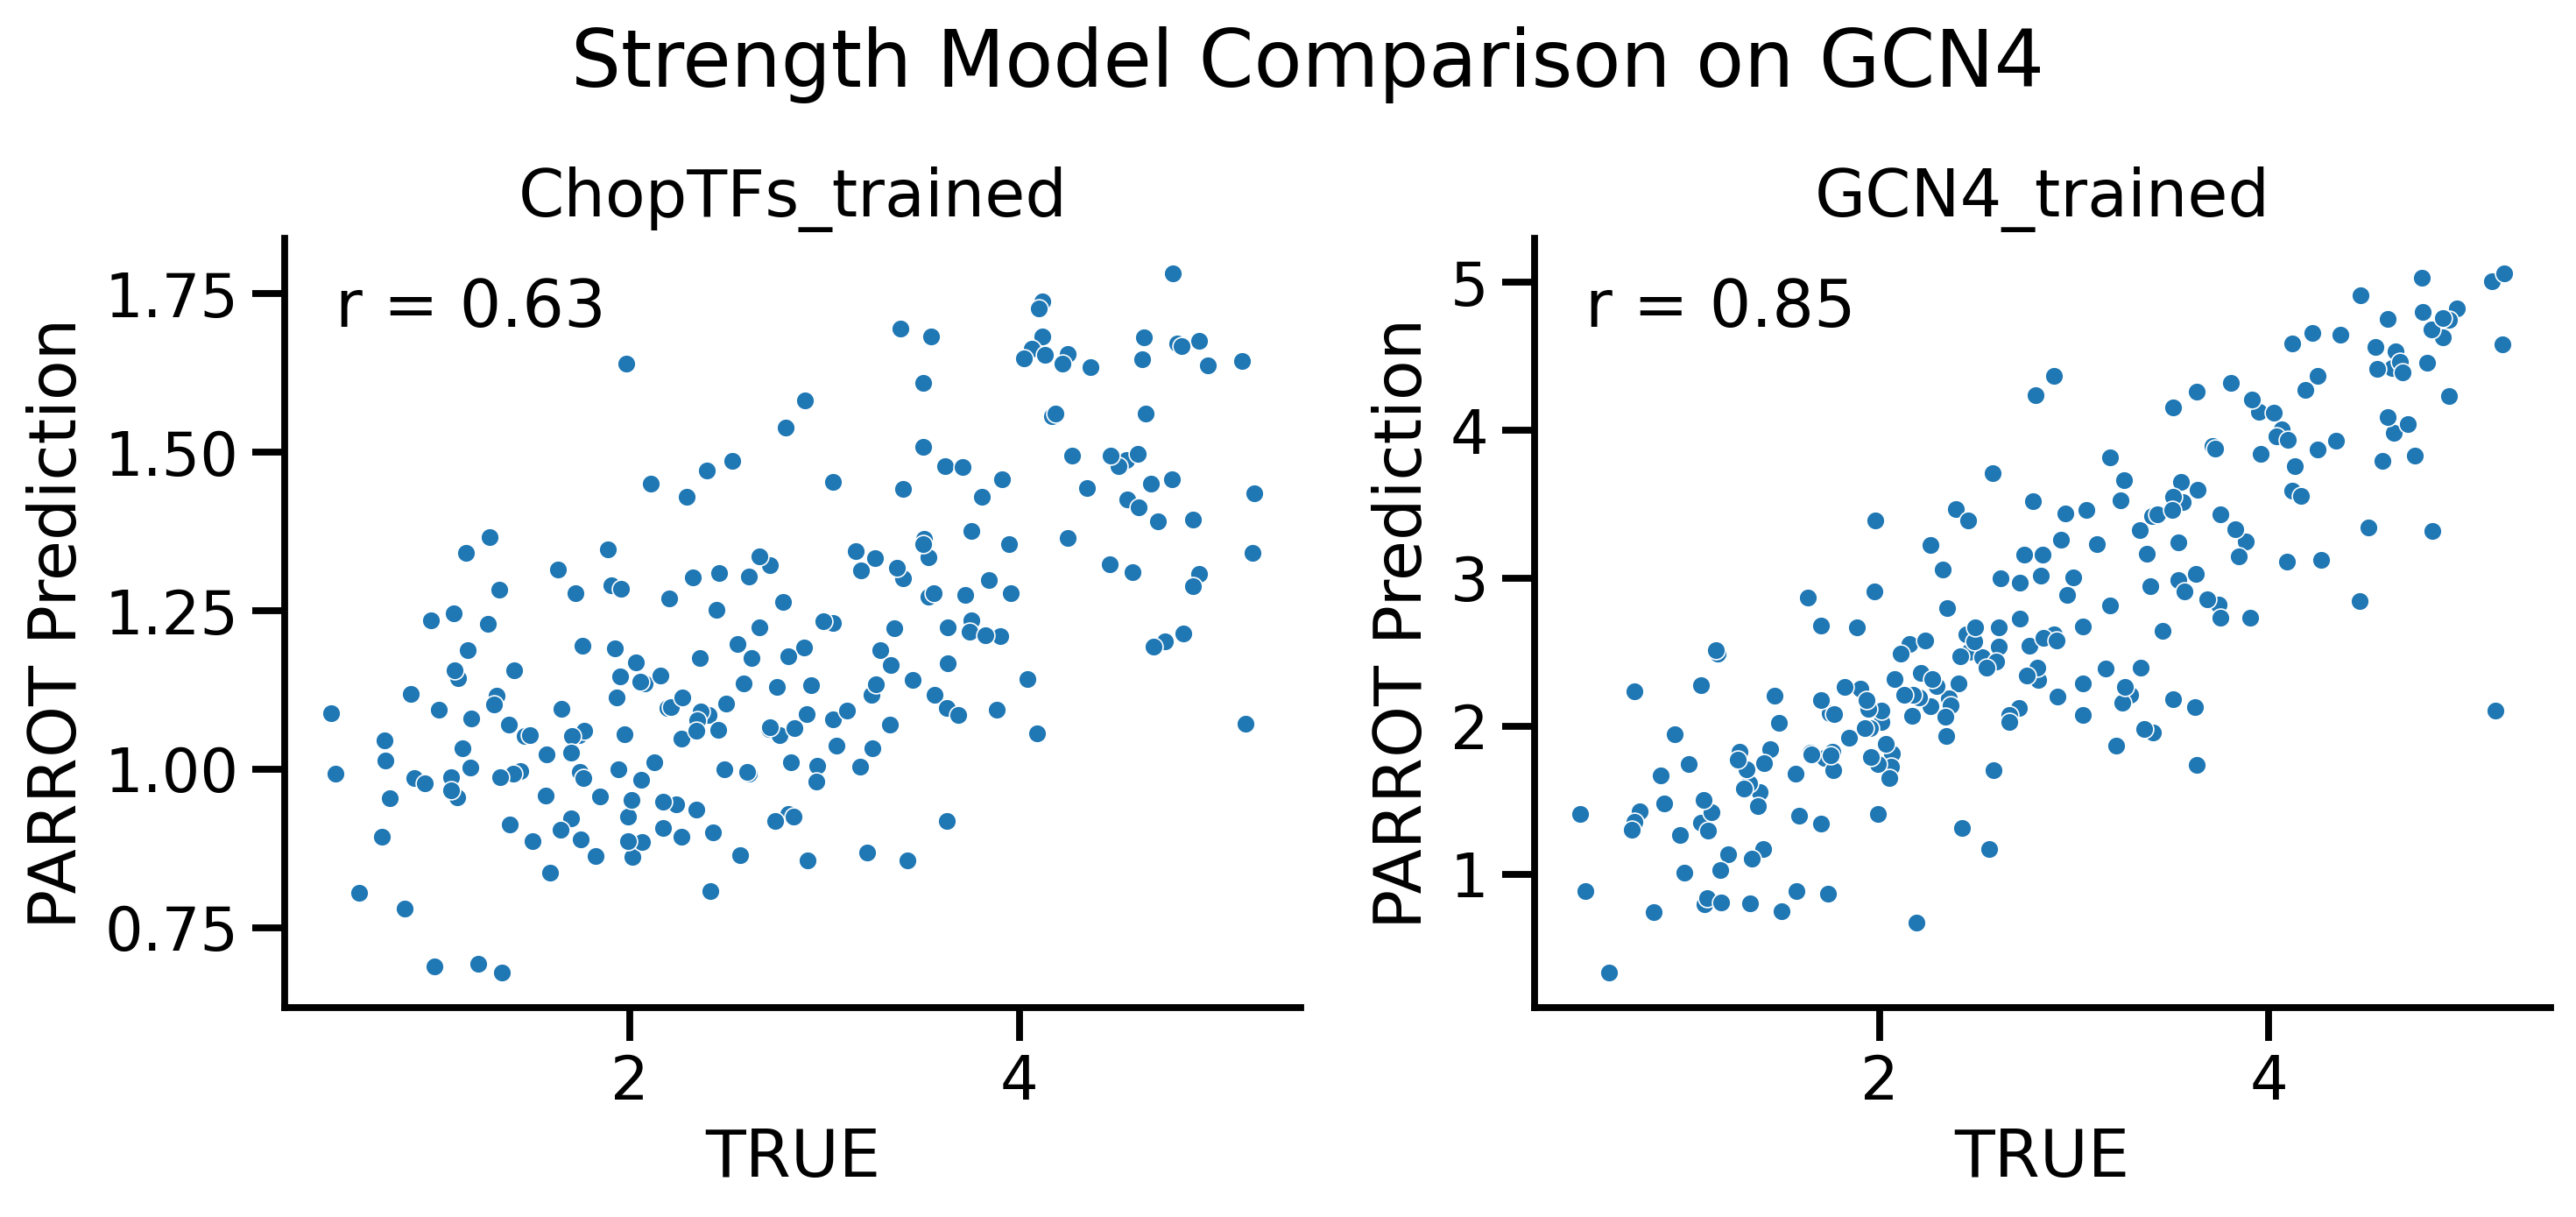

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

sns.set_context("talk")

df = gcn4_strength_preds.rename(columns = {"PRED" : "GCN4_trained", "ChopTFs_pred" : "ChopTFs_trained"})
cols = ["ChopTFs_trained", "GCN4_trained"]
true = df["TRUE"]

fig, axes = plt.subplots(1, 2, figsize=(10,5), sharex=True, dpi = 300)

for ax, col in zip(axes, cols):
    x = true
    y = df[col]

    sns.scatterplot(x=x, y=y, ax=ax, s=25, alpha=1)

    # Pearson
    r, _ = pearsonr(x, y)
    ax.text(
        0.05, 0.95,
        f"r = {r:.2f}",
        transform=ax.transAxes,
        va="top"
    )

    ax.set_title(f"{col}")
    ax.set_xlabel("TRUE")
    ax.set_ylabel("PARROT Prediction")

fig.suptitle("Strength Model Comparison on GCN4", y = 0.94)
sns.despine()
plt.tight_layout()
plt.show()